In [1]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [2]:
DATA_DIR = "proxima-hf-1"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Feedline Pressure",
           "pres_3": "PT3 Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure"}

# DRIVERS = {0: {"name": "Ox Fill", "false": "Close", "true": "Open"},
#            1: {"name": "Ground Vent", "false": "Close", "true": "Open"},
#            2: {"name": "Pressurization", "false": "Open", "true": "Close"},
#            3: {"name": "Engine Vent", "false": "Close", "true": "Open"},
#            4: {"name": "Ignition", "false": "Shutoff", "true": "Ignite"}}

In [3]:
# Manually locating timestamps for events

prep.process_data(DATA_DIR, SENSORS)
from time import time


contents = []
ignition_index = 0
samples_before_ignition = 0

with open(f"{DATA_DIR}/data-raw/console.log", 'r') as file:
    while True:
        line = file.readline()
        if len(line) <= 1:
            break
        contents.append(line)
for message in contents:
    if "Ignition in 10" in message:
        print(message, contents.index(message))
        ignition_index = contents.index(message)
        break
#gets the data log of the number of samples sent to approximate
#the 'start time'
for idx in range(ignition_index,0,-1):
    if "samples obtained" in contents[idx]:
        samples_before_ignition = int(contents[idx].split(':')[2].split()[0])
        temp_index = contents.index(contents[idx])
        message_count = 0
        for i in range(temp_index, ignition_index, 1):
            if "Sending data to" in contents[i]:
                message_count += 1   
        time_since_start_approx = round(samples_before_ignition/300)
        time_since_start = time_since_start_approx + round(message_count/2)
        break


FileNotFoundError: [Errno 2] No such file or directory: 'proxima-hf-1/data-raw/console.log'

In [4]:
print("Processing events")
# prep.process_events(DATA_DIR, DRIVERS)
print("Processing data")
prep.process_data(DATA_DIR, SENSORS)
print("Done!")
# 33
# 6509

Processing events
Processing data
Done!


In [25]:
# events = prep.import_events(DATA_DIR)
# print(events[52])
events = [{'secs': '5854', 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': '6000', 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
labels, data = prep.import_data(DATA_DIR, events)
print(labels)
times = data[:, 0]
print(times)

print(f"HF1 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

['Time (s)' 'LC1 Axial Load' 'PT1 Combustion Chamber Pressure'
 'PT2 Feedline Pressure' 'PT3 Injector Pressure' 'PT4 Ox-Tank Pressure']
[0.00000000e+00 3.33000000e-03 6.67000000e-03 ... 5.99999333e+03
 5.99999667e+03 6.00000000e+03]
HF1 Data Summary 
----------------- 
 Sensors: 5 
 Samples: 1800001 
 Events:  2


In [26]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=10, window="blackman")

5854.0
1756200
[  -48.27159   -44.40762   -46.16397 ... -3671.37661 -3689.29191
 -3688.94064]


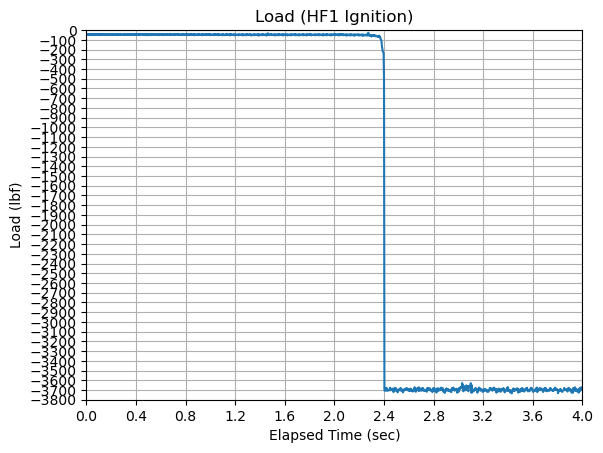

In [28]:
ep.plot(sensor_id=1, event_id=0, duration=4, filter=None,
        title="Load (HF1 Ignition)", ylabel="Load (lbf)",
        num_xticks=11, dif_yticks=100)

5854.0
1756200
[ 1.53327  1.03408 -0.29708 ... -0.46347  0.70129  1.03408]


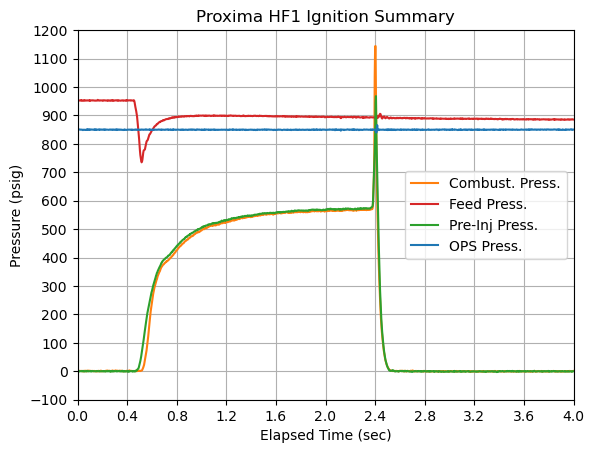

In [31]:
ep.plot(sensor_id=2, event_id=0, duration=4, filter=None,
        title="Proxima HF1 Ignition Summary", ylabel="Pressure (psig)",
        legend="Combust. Press.", num_xticks=11, dif_yticks=100, color="tab:orange")
ep.add_curve(sensor_id=3, event_id=0, duration=4, legend="Feed Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=0, duration=4, legend="Pre-Inj Press.",
             color="tab:green")
ep.add_curve(sensor_id=5, event_id=0, duration=4, legend="OPS Press.", 
             color="tab:blue")
plt.show()